## Spotify Music Clustering Project

Music streaming platforms like Spotify generate vast amounts of data related to song characteristics, user preferences, and listening habits. Understanding patterns in this data can help in tasks such as music recommendation, playlist generation, and genre discovery. In this project you are to focus on using clustering techniques to group songs based on their audio features, uncovering hidden structures in the dataset. By analyzing these clusters, one can gain insights into different music styles and potentially enhance recommendation systems.

### 1. Load necessary libraries & Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#load the dataset
data=pd.read_csv(r"D:\Advanced_Machine_Learning\Clustering_Algorithms\dataset\ML_spotify_data.csv")
data.head()

,name,artists,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,We're For The Dark - Remastered 2010,['Badfinger'],22,0.678,0.559,0.432,0,3,0.0727,-12.696,0.0334,117.674
1,Sixty Years On - Piano Demo,['Elton John'],25,0.456,0.259,0.368,0,6,0.1560,-10.692,0.0280,143.783
2,Got to Find Another Way,['The Guess Who'],21,0.433,0.833,0.724,0,0,0.1700,-9.803,0.0378,84.341
3,Feelin' Alright - Live At The Fillmore East/1970,['Joe Cocker'],22,0.436,0.870,0.914,0,5,0.8550,-6.955,0.0610,174.005
4,Caravan - Take 7,['Van Morrison'],23,0.669,0.564,0.412,0,7,0.4010,-13.095,0.0679,78.716


In [3]:
#check and drop for duplicates
data[data.duplicated()]
data.drop_duplicates(inplace=True)

In [4]:
#check for missingness
data.isnull().sum()

name            0
artists         0
popularity      0
danceability    0
valence         0
energy          0
explicit        0
key             0
liveness        0
loudness        0
speechiness     0
tempo           0
dtype: int64

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9999 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          9999 non-null   object 
 1   artists       9999 non-null   object 
 2   popularity    9999 non-null   int64  
 3   danceability  9999 non-null   float64
 4   valence       9999 non-null   float64
 5   energy        9999 non-null   float64
 6   explicit      9999 non-null   int64  
 7   key           9999 non-null   int64  
 8   liveness      9999 non-null   float64
 9   loudness      9999 non-null   float64
 10  speechiness   9999 non-null   float64
 11  tempo         9999 non-null   float64
dtypes: float64(7), int64(3), object(2)
memory usage: 1015.5+ KB


### 2. Exploratory Data Analysis (EDA)

In [6]:
num_df=data.select_dtypes(include=np.number)
cat_df=data.select_dtypes(exclude=np.number)

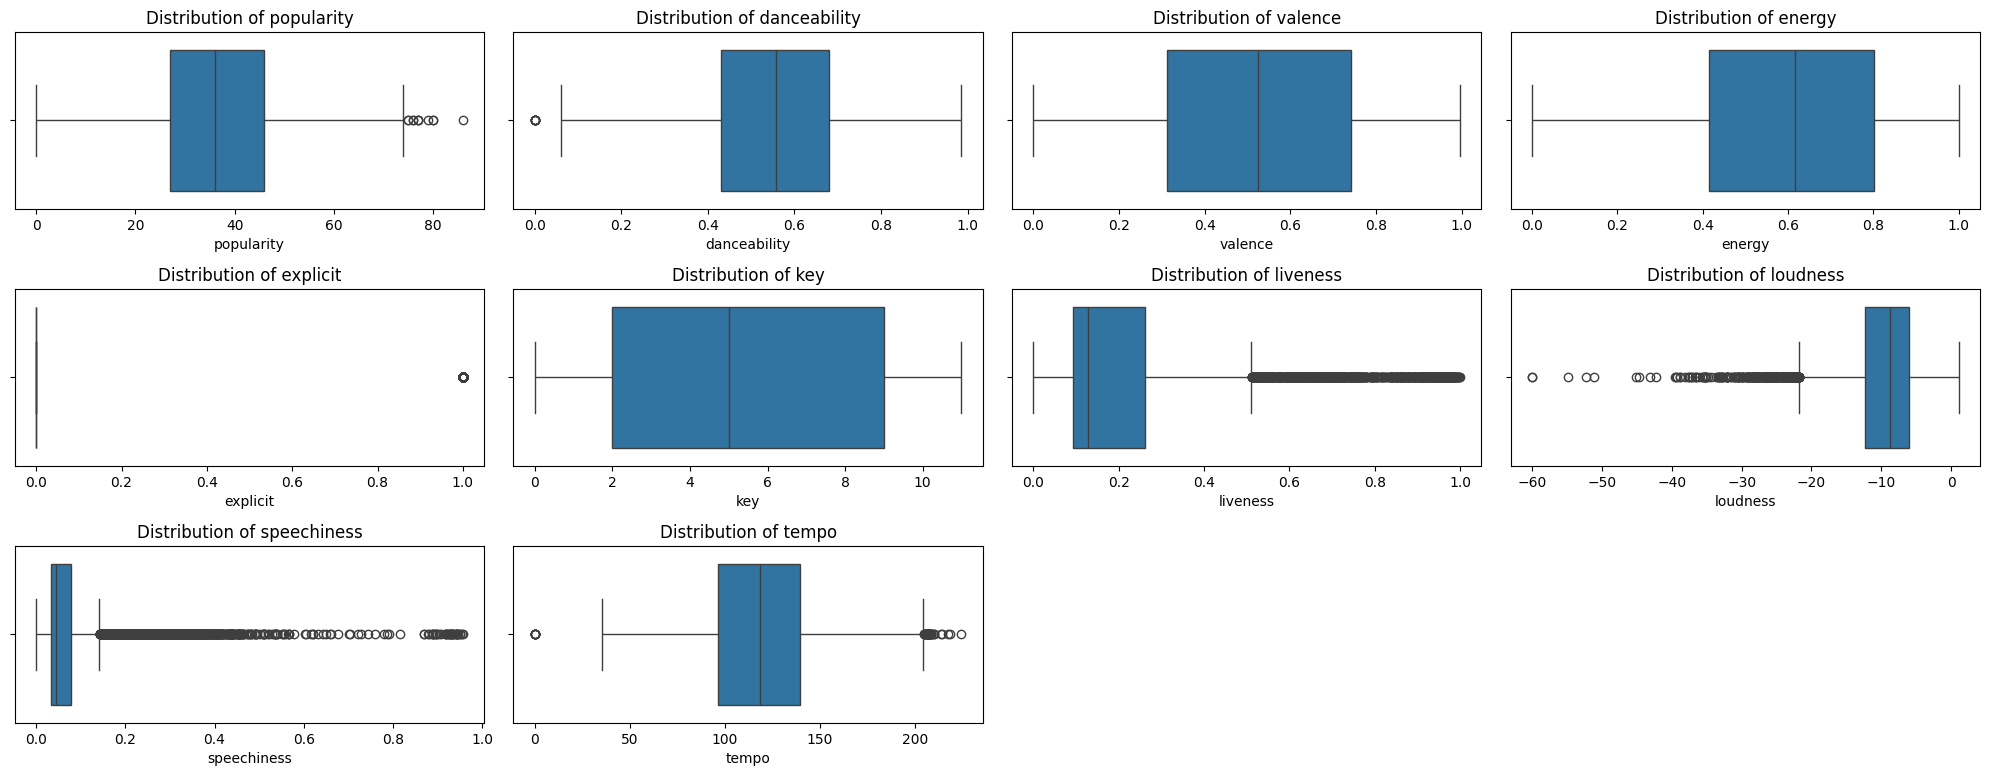

In [10]:
fig=plt.figure(figsize=(20,10))
for i in range(len(num_df.columns)):
    plt.subplot(4,4,i+1)
    sns.boxplot(x=num_df.columns[i],data=num_df)
    plt.title("Distribution of " + num_df.columns[i])
    plt.xlabel(num_df.columns[i])
plt.tight_layout()
plt.show()

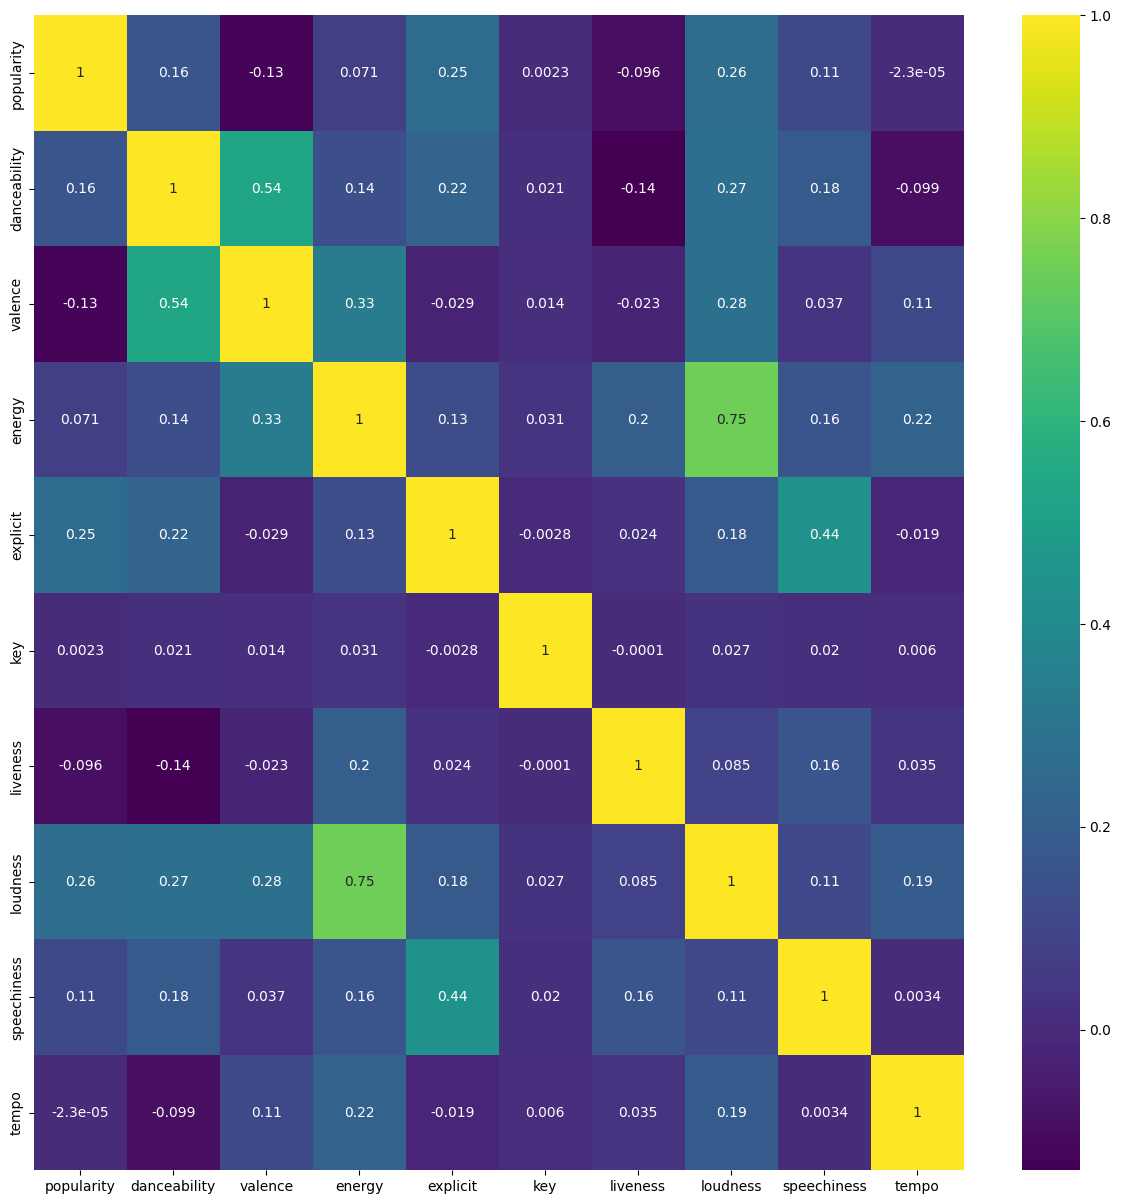

In [11]:
#correlation matrix
corrmat = num_df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(15,15))
g=sns.heatmap(num_df[top_corr_features].corr(),annot=True,cmap="viridis")

### 3. Data pre-processsing & preparation

In [15]:
# feature scaling
from sklearn.preprocessing import StandardScaler, RobustScaler

df=num_df.copy()
scaler=RobustScaler()
scaled_df=scaler.fit_transform(df)
scaled_df=pd.DataFrame(scaled_df, columns=df.columns)

In [16]:
scaled_df.head()

,popularity,danceability,valence,energy,explicit,key,liveness,loudness,speechiness,tempo
0,-0.736842,0.482072,0.081585,-0.475452,0.0,-0.285714,-0.336924,-0.626792,-0.270833,-0.015062
1,-0.578947,-0.402390,-0.617716,-0.640827,0.0,0.142857,0.161580,-0.307582,-0.395833,0.586230
2,-0.789474,-0.494024,0.720280,0.279070,0.0,-0.714286,0.245362,-0.165976,-0.168981,-0.782723
3,-0.736842,-0.482072,0.806527,0.770026,0.0,0.000000,4.344704,0.287671,0.368056,1.282245
4,-0.684211,0.446215,0.093240,-0.527132,0.0,0.285714,1.627768,-0.690347,0.527778,-0.912267


### 4. Clustering Algorithms

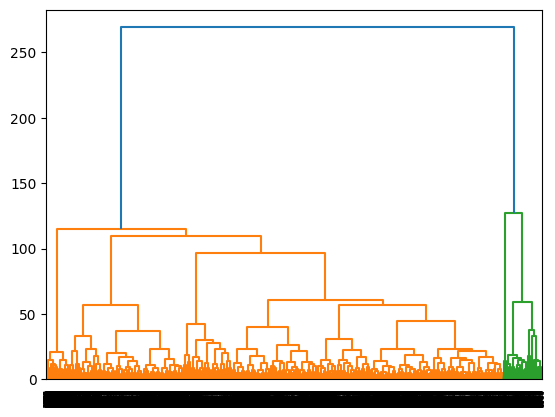

In [ ]:
#start with hierarchical clustering- just to identify the number of clusters, roughly
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

wards_clustering = linkage(scaled_df, method="ward")
dendrogram(wards_clustering)
plt.show()

NOTE: Please note, for hierarchical clustering, because I am just using it to give me an idea of a good value of clusters for my other clustering algorithms I used a simple library called scipy, please run ```pip install scipy``` on your terminal to get started with it. Why did I use it? because the library has a native way of plotting dendograms- which is what I want, so that I can see any natural groupings in my data.

In [21]:
#apply K-means clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=0,init='k-means++',n_init="auto").fit(scaled_df)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_


print(centroids)
print("\nCluster Labels for Data Points:")
print(labels)

[[ 1.35252277e-01  1.22386654e-01  1.79129026e-01  1.78650406e-01
   7.36374509e-02  3.69285592e-02  1.78734164e-01  1.50818310e-01
   2.51979042e-01  1.22962137e-01]
 [-1.33166443e-01 -3.70942679e-01 -6.54097913e-02  2.55526664e-01
   5.10440835e-02  2.90023202e-02  3.39320551e+00 -1.88750685e-02
   5.77661768e-01  1.49537316e-01]
 [-1.84603299e-01  6.90372837e-02 -1.91977177e-01 -8.92822708e-02
   4.47761194e-01 -2.13219616e-03  2.59029806e+00 -7.96194244e-01
   1.78462894e+01 -3.51386556e-01]
 [-1.11560150e-01 -5.13827547e-01 -4.88214086e-01 -9.09630761e-01
   8.03571429e-03 -1.27551020e-03  7.42241600e-02 -1.21301071e+00
  -9.98305225e-02 -2.06117978e-01]
 [ 4.14911383e-01  4.61704869e-01  9.62944936e-02  1.76924250e-01
   5.20982600e-01  5.73183214e-02  5.31440364e-01  2.18510123e-01
   5.59290297e+00  6.44629455e-02]]

Cluster Labels for Data Points:
[3 3 0 ... 0 4 0]


In [22]:
from sklearn.metrics import silhouette_score
silhouette_score(scaled_df, kmeans.labels_, metric='euclidean')

0.22553118038327652

##### Finding the right value for k

In [23]:
inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0,init='k-means++',n_init="auto").fit(scaled_df)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(scaled_df, kmeans.labels_))

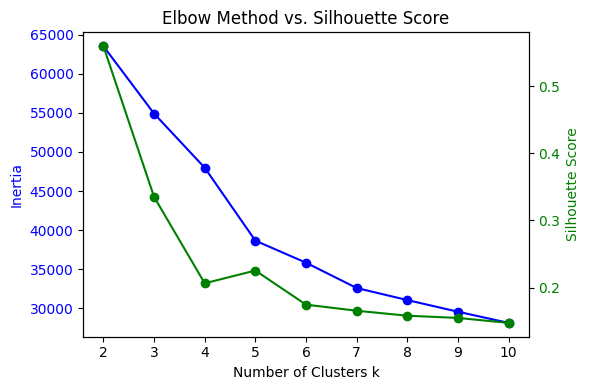

In [24]:
fig, ax1 = plt.subplots(figsize=(6, 4))

# Inertia (Elbow Method)
ax1.plot(k_range, inertias, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters k')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

#Silhouette Score
ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 'go-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='g')
ax2.tick_params(axis='y', labelcolor='g')

plt.title('Elbow Method vs. Silhouette Score')
fig.tight_layout()
plt.show()

In [25]:
kmeans_final = KMeans(n_clusters=5, random_state=42, 
                      init='k-means++', n_init='auto')
kmeans_final.fit(scaled_df)
labels_kmeans = kmeans_final.labels_

In [26]:
import collections
print(collections.Counter(labels_kmeans))

Counter({np.int32(4): 5850, np.int32(0): 2243, np.int32(3): 976, np.int32(2): 863, np.int32(1): 67})


In [27]:
#apply gaussian mixture model
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5,covariance_type='full', random_state=42)

# Fit the model
gmm.fit(scaled_df)

# Get cluster labels and probabilities
labels = gmm.predict(scaled_df)
probs = gmm.predict_proba(scaled_df)

In [28]:
import collections
print(collections.Counter(labels))

Counter({np.int64(0): 3722, np.int64(4): 3477, np.int64(2): 1704, np.int64(3): 1011, np.int64(1): 85})


##### Optimizing for the number of gaussian components

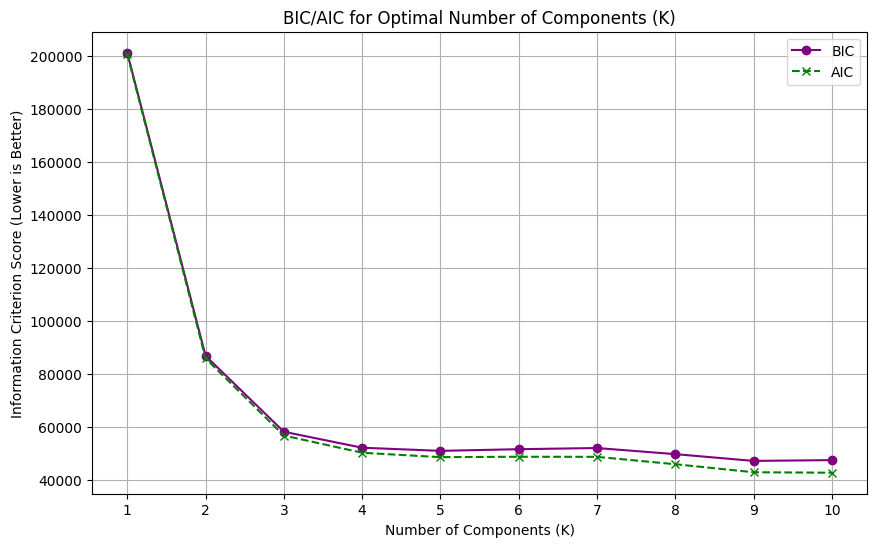

In [29]:
k_range = range(1, 11)
bic = []
aic = []


for k in k_range:
    gmm = GaussianMixture(n_components=k,covariance_type='full', random_state=42)
    gmm.fit(scaled_df)
    
    bic.append(gmm.bic(scaled_df))
    aic.append(gmm.aic(scaled_df))

# 3. Plot the BIC and AIC scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, bic, marker='o', linestyle='-', color='purple', label='BIC')
plt.plot(k_range, aic, marker='x', linestyle='--', color='green', label='AIC')
plt.title('BIC/AIC for Optimal Number of Components (K)')
plt.xlabel('Number of Components (K)')
plt.ylabel('Information Criterion Score (Lower is Better)')
plt.xticks(k_range)
plt.legend()
plt.grid(True)

plt.show()

In [30]:
gmm_final = GaussianMixture(n_components=3,covariance_type='full', random_state=42)
gmm_final.fit(scaled_df)
labels_gmm = gmm_final.predict(scaled_df)

print(collections.Counter(labels_gmm))

Counter({np.int64(0): 6002, np.int64(2): 2965, np.int64(1): 1032})


In [ ]:
#apply dbscan clustering
from sklearn.cluster import DBSCAN, HDBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(scaled_df)

print(collections.Counter(labels_dbscan))
print(f"\nNoise points (label=-1): {(labels_dbscan == -1).sum()}")
print(f"Number of clusters found: {len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)}")

Counter({np.int64(-1): 9766, np.int64(5): 20, np.int64(22): 18, np.int64(28): 15, np.int64(6): 12, np.int64(26): 10, np.int64(1): 7, np.int64(3): 7, np.int64(12): 7, np.int64(7): 7, np.int64(16): 6, np.int64(9): 5, np.int64(21): 5, np.int64(18): 5, np.int64(0): 5, np.int64(17): 5, np.int64(8): 5, np.int64(2): 5, np.int64(4): 5, np.int64(10): 5, np.int64(15): 5, np.int64(20): 5, np.int64(11): 5, np.int64(13): 5, np.int64(24): 5, np.int64(14): 5, np.int64(27): 5, np.int64(19): 5, np.int64(31): 5, np.int64(30): 5, np.int64(23): 5, np.int64(25): 5, np.int64(33): 5, np.int64(32): 5, np.int64(29): 5, np.int64(34): 4})

Noise points (label=-1): 9766
Number of clusters found: 35


### Cluster Analysis